# 12 — GIS & VTK Exports

Get an IWFM model out of text files and into GIS — and into 3D.

**Part 1 — GIS** (`iwfm_io.gis`): the model's spatial layers as
geopandas GeoDataFrames and standard GIS formats:

- **`export_gis()` / `model.to_gis()`** — one call, every layer, to a
  multi-layer **GeoPackage** (recommended) or a folder of **ESRI
  Shapefiles**
- **per-layer builders** (`nodes_gdf`, `elements_gdf`,
  `subregions_gdf`, `streams_gdf`, `stream_nodes_gdf`, `lakes_gdf`,
  `tile_drains_gdf`, `wells_gdf`) — GeoDataFrames for use in Python
- **attribute joins** — carry simulation results (heads, depth to
  water, land use…) onto the exported layers

**Part 2 — VTK** (`iwfm_io.vtk`): the model as a **3D layered mesh**
for [ParaView](https://www.paraview.org) — `export_vtk()` /
`model.to_vtk()` for the static mesh, `export_vtk_timeseries()` for
an animated heads `.pvd`. Written with plain numpy: **no VTK library
to install**.

Geometry is built from node coordinates and element configurations,
so any model source works: an `open_model()` adapter **or** a DLL
`IWFMModel`.

**Requires:** the sample model and `pip install iwfm-io[geo]`
(geopandas + shapely) for Part 1. Part 2 needs nothing beyond
`iwfm-io` itself; the optional inline 3D preview uses `pyvista` if
it happens to be installed.

In [1]:
import os
import tempfile
from pathlib import Path


def find_sample_model():
    env = os.environ.get("IWFM_SAMPLE_MODEL")
    if env:
        return Path(env)
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / ".assets" / "sample_model"
        if cand.is_dir():
            return cand
    raise FileNotFoundError("sample model not found — see notebook 01")


SAMPLE_MODEL = find_sample_model()
WORK = Path(tempfile.mkdtemp(prefix="iwfm_nb12_"))

from iwfm_io import open_model

model = open_model(SAMPLE_MODEL)
print(f"{model.n_nodes} nodes, {model.n_elements} elements, "
      f"{model.n_reaches} reaches, {model.n_subregions} subregions")

441 nodes, 400 elements, 3 reaches, 2 subregions


## One call: `to_gis()`

A `.gpkg` destination writes one multi-layer GeoPackage. Every layer
the model can provide is included; unavailable or empty layers are
skipped with a log message (the sample model pumps by element, so its
`wells` layer is empty and skipped).

**A note on `crs=`:** IWFM input files carry coordinates but no
coordinate reference system. Pass the model's projection if you know
it — DWR's Central Valley models are commonly UTM Zone 10N
(`EPSG:26910`) or NAD83 California Albers (`EPSG:3310`) — so the
layers land georeferenced in GIS software. Without it they are written
unreferenced (still perfectly usable, just not on a basemap).

In [2]:
gpkg = WORK / "sample_model.gpkg"
written = model.to_gis(gpkg, crs="EPSG:26910")
written

{'nodes': 441,
 'elements': 400,
 'subregions': 2,
 'streams': 3,
 'stream_nodes': 23,
 'lakes': 1,
 'tile_drains': 21}

In [3]:
# The GeoPackage is a normal geopandas/QGIS/ArcGIS file — read any layer
import geopandas as gpd

subregions = gpd.read_file(gpkg, layer="subregions")
print("CRS:", subregions.crs)
subregions

CRS: EPSG:26910


,subregion_id,name,n_elements,area,geometry
0,1,Region1,200,800000000.0,"POLYGON ((550000 4412000, 550000 4414000, 5500..."
1,2,Region2,200,800000000.0,"POLYGON ((550000 4432000, 550000 4434000, 5500..."


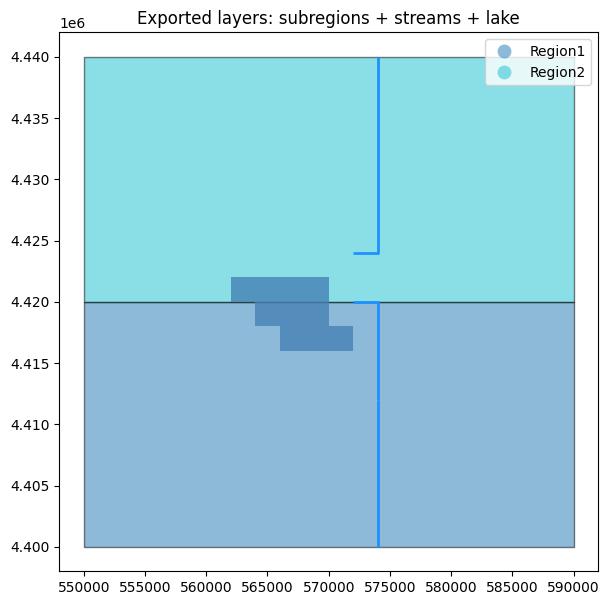

In [4]:
# GeoDataFrames plot directly — subregions with the stream network on top
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))
subregions.plot(ax=ax, column="name", legend=True, alpha=0.5,
                edgecolor="black")
gpd.read_file(gpkg, layer="streams").plot(ax=ax, color="dodgerblue",
                                          linewidth=2)
gpd.read_file(gpkg, layer="lakes").plot(ax=ax, color="steelblue",
                                        alpha=0.8)
ax.set_title("Exported layers: subregions + streams + lake")
ax.set_aspect("equal")
plt.show()

## The layers

| Layer | Geometry | Key attributes |
|-------|----------|----------------|
| `nodes` | Point | `node_id`, `x`, `y` + stratigraphy (GSE, layer thicknesses) |
| `elements` | Polygon | `element_id`, `node1`–`node4`, `subregion`, `subregion_name` |
| `subregions` | Polygon (dissolved) | `subregion_id`, `name`, `n_elements`, `area` |
| `streams` | LineString (one per reach) | `reach_id`, `name`, `n_nodes`, `outflow_dest` |
| `stream_nodes` | Point | `stream_node_id`, `reach_id`, `gw_node_id` |
| `lakes` | Polygon (merged elements) | `lake_id`, `n_elements` |
| `tile_drains` | Point | `id`, `node` |
| `wells` | Point | `well_id`, `radius`, `perf_top`, `perf_bot`, `name` |

## Per-layer builders

Each layer is also available as a GeoDataFrame without writing
anything — useful for spatial analysis right in Python. `nodes_gdf`
joins the stratigraphy table by default, so ground-surface elevation
and layer thicknesses ride along.

In [5]:
from iwfm_io import nodes_gdf

nodes = nodes_gdf(model, crs="EPSG:26910")
nodes.head(3)

,node_id,x,y,elevation,aquitard_1,aquifer_1,aquitard_2,aquifer_2,geometry
0,1,550000.0,4400000.0,500.0,0.0,500.0,10.0,100.0,POINT (550000 4400000)
1,2,552000.0,4400000.0,500.0,0.0,500.0,10.0,100.0,POINT (552000 4400000)
2,3,554000.0,4400000.0,500.0,0.0,500.0,10.0,100.0,POINT (554000 4400000)


In [6]:
from iwfm_io import subregions_gdf

# dissolved polygons carry element counts and areas (model units²)
subregions_gdf(model).drop(columns="geometry")

,subregion_id,name,n_elements,area
0,1,Region1,200,800000000.0
1,2,Region2,200,800000000.0


In [7]:
# spatial operations work immediately — e.g. total stream length per subregion
from iwfm_io import streams_gdf

streams = streams_gdf(model, crs="EPSG:26910")
joined = gpd.sjoin(streams, subregions_gdf(model, crs="EPSG:26910"),
                   how="left", predicate="intersects")
joined.groupby("name_right")["geometry"].apply(
    lambda g: streams.loc[g.index].length.sum() / 5280.0).rename("stream_miles")

name_right
Region1    4.166667
Region2    5.303030
Name: stream_miles, dtype: float64

## Carrying results onto the layers

`node_data=` / `element_data=` merge any per-node / per-element
DataFrame onto those layers (keyed `node_id` / `element_id`). Classic
use: export end-of-simulation heads and depth to water so they can be
symbolized in GIS.

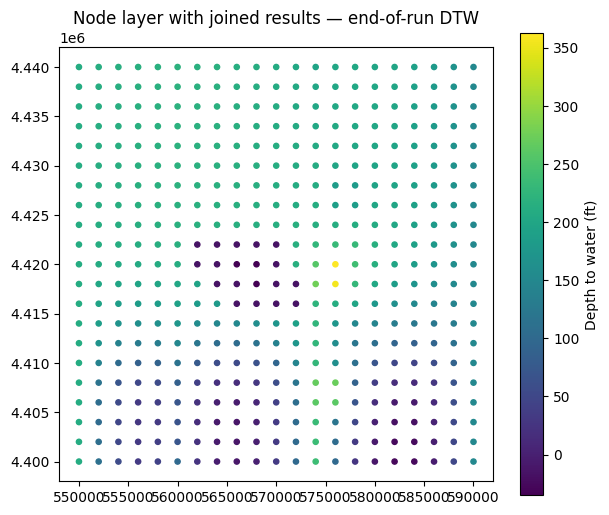

In [8]:
import pandas as pd

heads = model.heads_df(layer=1)
strat = model.stratigraphy_df()
node_results = pd.DataFrame({
    "node_id": strat["node_id"],
    "head_end": heads.iloc[-1].values,
    "dtw_end": strat["elevation"].values - heads.iloc[-1].values,
})

model.to_gis(WORK / "results.gpkg", layers=["nodes"],
             node_data=node_results, crs="EPSG:26910")

back = gpd.read_file(WORK / "results.gpkg", layer="nodes")
fig, ax = plt.subplots(figsize=(7, 6))
back.plot(ax=ax, column="dtw_end", markersize=14, legend=True,
          legend_kwds={"label": "Depth to water (ft)"})
ax.set_title("Node layer with joined results — end-of-run DTW")
ax.set_aspect("equal")
plt.show()

In [9]:
# element joins work the same way — e.g. tag elements by any zonation
elems = model.elements_df()
element_zones = pd.DataFrame({
    "element_id": elems["element_id"],
    "calib_zone": ["north" if s == 1 else "south"
                   for s in elems["subregion"]],
})
model.to_gis(WORK / "results.gpkg", layers=["elements"],
             element_data=element_zones, crs="EPSG:26910")
gpd.read_file(WORK / "results.gpkg", layer="elements").head(3)[
    ["element_id", "subregion_name", "calib_zone"]]

,element_id,subregion_name,calib_zone
0,1,Region1,north
1,2,Region1,north
2,3,Region1,north


## Shapefiles instead of GeoPackage

Any non-`.gpkg` destination is treated as a directory and gets one
ESRI Shapefile per layer. (Prefer GeoPackage when you can — shapefiles
truncate column names to 10 characters, which geopandas warns about.)

In [10]:
import warnings

shp_dir = WORK / "shapefiles"
with warnings.catch_warnings():
    warnings.simplefilter("ignore")   # silence the name-truncation chatter
    model.to_gis(shp_dir, layers=["nodes", "elements", "streams"],
                 crs="EPSG:26910")
sorted(p.name for p in shp_dir.iterdir())

['elements.cpg',
 'elements.dbf',
 'elements.prj',
 'elements.shp',
 'elements.shx',
 'nodes.cpg',
 'nodes.dbf',
 'nodes.prj',
 'nodes.shp',
 'nodes.shx',
 'streams.cpg',
 'streams.dbf',
 'streams.prj',
 'streams.shp',
 'streams.shx']

## Works from the DLL model too

The builders only need the `nodes_df()`/`elements_df()` interface, so
a DLL `IWFMModel` (notebook 05) exports the same way:

```python
with iwfm_io.dll.IWFMModel(preprocessor_file=..., simulation_file=...,
                           is_for_inquiry=True) as m:
    export_gis(m, "model.gpkg", crs="EPSG:26910")
```

Layers that inquiry mode cannot serve (e.g. tile drains on some
models) are skipped with a log message instead of failing the export.

---
# Part 2 — VTK: the model in 3D

GIS layers are flat. `export_vtk()` builds the actual **3D aquifer
mesh**: the finite-element grid extruded through the stratigraphy —
triangles become wedges, quadrilaterals become hexahedra, one cell
layer per aquifer. Each layer gets its own top and bottom surfaces
following IWFM's convention (a layer's aquitard sits *above* its
aquifer), so aquitard gaps between layers are represented faithfully.

Every export carries `layer`, `thickness`, `element_id`, and
`subregion` cell arrays and a `node_id` point array; add your own with
`point_data=` / `cell_data=`.

One practical tip: regional aquifers are hundreds of times wider than
they are thick — pass a **vertical exaggeration** via `z_scale`
(20–100 for real models) or the mesh renders as a sheet of paper.

In [11]:
info = model.to_vtk(WORK / "sample_model.vtu", z_scale=8.0)
info

{'path': 'C:\\Users\\serca\\AppData\\Local\\Temp\\iwfm_nb12_98l8669h\\sample_model.vtu',
 'n_points': 1764,
 'n_cells': 800,
 'layers': [1, 2]}

## Add data arrays

Per-node arrays shaped `(n_nodes,)` apply to every layer; shaped
`(n_nodes, n_layers)` they vary by layer — perfect for heads.

In [12]:
import numpy as np

from iwfm_io import export_vtk

head_end = np.column_stack([model.heads_df(layer=k).iloc[-1].values
                            for k in (1, 2)])
info = export_vtk(model, WORK / "sample_model_heads.vtu",
                  point_data={"head_end": head_end}, z_scale=8.0)
info

{'path': 'C:\\Users\\serca\\AppData\\Local\\Temp\\iwfm_nb12_98l8669h\\sample_model_heads.vtu',
 'n_points': 1764,
 'n_cells': 800,
 'layers': [1, 2]}

## Inline 3D preview (optional)

The `.vtu` is meant for ParaView, but with `pyvista` installed
(`pip install pyvista`) we can render a preview right here — cells
colored by aquifer layer, edges on.

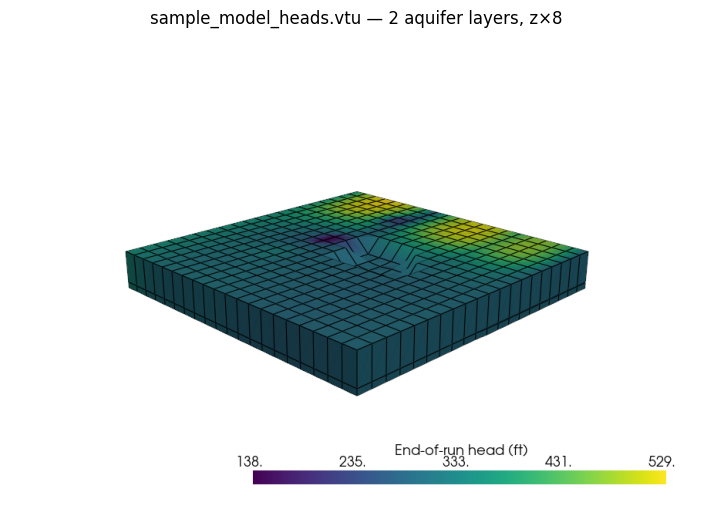

In [13]:
try:
    import pyvista as pv

    grid = pv.read(WORK / "sample_model_heads.vtu")
    pl = pv.Plotter(off_screen=True, window_size=(900, 620))
    pl.add_mesh(grid, scalars="head_end", show_edges=True, cmap="viridis",
                scalar_bar_args={"title": "End-of-run head (ft)"})
    pl.camera_position = "xz"
    pl.camera.azimuth = 225
    pl.camera.elevation = 20
    img = pl.screenshot(return_img=True)

    plt.figure(figsize=(9, 6.2))
    plt.imshow(img)
    plt.axis("off")
    plt.title("sample_model_heads.vtu — 2 aquifer layers, z×8")
    plt.show()
except ImportError:
    print("pyvista not installed — open the .vtu in ParaView instead")

## Animated heads: `export_vtk_timeseries`

One `.vtu` per (strided) timestep carrying `head` and `dtw` (depth to
water) point arrays, plus a `.pvd` collection file. Open the `.pvd`
in ParaView, color by `head`, and press play.

In [14]:
from iwfm_io import export_vtk_timeseries

ts = export_vtk_timeseries(
    model, WORK / "anim",
    begin_date="10/01/1990_24:00", end_date="09/30/1992_24:00",
    stride=91,                       # daily output -> quarterly frames
    z_scale=8.0)
print(ts)
sorted(p.name for p in (WORK / "anim").iterdir())

{'pvd': 'C:\\Users\\serca\\AppData\\Local\\Temp\\iwfm_nb12_98l8669h\\anim\\heads.pvd', 'n_steps': 9, 'n_cells': 800}


['heads.pvd',
 'heads_0000.vtu',
 'heads_0001.vtu',
 'heads_0002.vtu',
 'heads_0003.vtu',
 'heads_0004.vtu',
 'heads_0005.vtu',
 'heads_0006.vtu',
 'heads_0007.vtu',
 'heads_0008.vtu']

In [15]:
# the .pvd is a tiny XML index — timestep = days since the first frame
print((WORK / "anim" / "heads.pvd").read_text())

<?xml version="1.0"?>
<VTKFile type="Collection" version="0.1" byte_order="LittleEndian">
  <Collection>
    <DataSet timestep="0" part="0" file="heads_0000.vtu"/>
    <DataSet timestep="91" part="0" file="heads_0001.vtu"/>
    <DataSet timestep="182" part="0" file="heads_0002.vtu"/>
    <DataSet timestep="273" part="0" file="heads_0003.vtu"/>
    <DataSet timestep="364" part="0" file="heads_0004.vtu"/>
    <DataSet timestep="455" part="0" file="heads_0005.vtu"/>
    <DataSet timestep="546" part="0" file="heads_0006.vtu"/>
    <DataSet timestep="637" part="0" file="heads_0007.vtu"/>
    <DataSet timestep="728" part="0" file="heads_0008.vtu"/>
  </Collection>
</VTKFile>


## Recap

```python
# GIS — flat layers for QGIS/ArcGIS ([geo] extra)
m.to_gis("model.gpkg", crs="EPSG:26910")          # everything, one file
m.to_gis("shp_folder", layers=["nodes"])          # shapefiles
export_gis(m, "model.gpkg", node_data=dtw_frame)  # results ride along
nodes_gdf(m); streams_gdf(m); subregions_gdf(m)   # GeoDataFrames in Python

# VTK — the 3D aquifer mesh for ParaView (no extra install)
m.to_vtk("model.vtu", z_scale=50)
export_vtk_timeseries(m, "anim", stride=30)       # -> anim/heads.pvd
```

The GeoPackage opens directly in QGIS (*Layer → Add Layer*, or
drag-and-drop) and ArcGIS Pro; the `.vtu`/`.pvd` open in ParaView
(*File → Open → Apply*).

In [16]:
import shutil

shutil.rmtree(WORK, ignore_errors=True)
print("workspace removed")

workspace removed
